# Temporal Features Generation

In [1]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

2026-04-04 16:29:57.162549: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-04 16:29:57.189736: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-04 16:29:57.742075: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
static_dataset_path = "https://leofernanndes-datasets.s3.us-east-1.amazonaws.com/ded-pta/20251128/static_inceptionresnetv2_merged_df.csv"
static_df = pd.read_csv(static_dataset_path)
static_df

,0,1,2,3,4,5,6,7,8,9,...,1531,1532,1533,1534,1535,current,nozzle_speed,mass_flow_rate,experiment,y
0,0.268668,2.135428,0.254319,1.120271,1.717007,2.525722,1.439569,1.197647,1.907200,2.698844,...,4.550923,0.976787,5.078724,0.916078,0.810310,120,60,10,L1,8.270000
1,1.796658,1.111642,2.173924,1.168855,1.958516,3.892386,2.254913,2.498463,2.026056,2.081994,...,2.352076,1.156320,4.846306,2.037605,2.383300,120,60,10,L1,8.275047
2,0.701214,1.457909,2.461075,0.660427,1.662844,4.082214,2.050429,2.159187,2.108297,1.818217,...,2.132257,0.693676,5.404124,1.505751,2.369541,120,60,10,L1,8.280094
3,0.552878,1.931452,1.279850,1.709836,3.026994,2.555729,2.568603,1.671118,1.262385,2.069554,...,1.725683,2.408711,6.181901,2.244930,1.437709,120,60,10,L1,8.285140
4,2.262700,0.768005,0.834891,1.736228,1.912862,3.624902,3.611040,1.741612,2.954618,2.291300,...,1.861496,1.336547,6.120957,1.452415,1.303899,120,60,10,L1,8.290184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26629,0.497132,1.609407,1.200686,1.115807,1.408667,2.894046,2.311125,2.159183,1.450033,0.874423,...,2.149302,2.812623,5.622643,1.740274,1.765032,200,100,20,L9,9.257003
26630,1.104252,1.617251,1.636759,1.000721,1.324411,3.693601,0.500405,1.819577,1.525216,2.053482,...,1.441833,0.517480,4.107387,1.356999,0.239261,200,100,20,L9,9.254914
26631,1.032116,1.754873,1.152957,0.608981,0.950851,3.300307,3.177645,2.462339,3.052878,0.428281,...,2.256836,1.693011,4.143994,1.896582,1.188057,200,100,20,L9,9.253064
26632,1.029153,1.891602,0.931702,1.405720,2.502486,4.084352,0.644090,1.336288,1.147039,0.997570,...,1.408675,1.592979,4.019584,2.043623,1.393690,200,100,20,L9,9.251459


## Generation of 100 previous images using the most naive method 

In [3]:
number_of_legs = 101
convolutional_features = static_df.copy()

val_loss_list_1 = []
val_r2_list_1 = []

for i in range(1, number_of_legs):

    x_train, x_test, y_train, y_test = train_test_split(convolutional_features.drop(['y', 'current', 'nozzle_speed', 'mass_flow_rate', 'experiment'], axis=1), convolutional_features['y'], train_size=0.7, random_state=42)

    model = keras.Sequential([
        keras.layers.Input(shape=(1536+i-1,)),  # Input layer
        keras.layers.Dense(32, activation='relu'),  # Hidden layer with 32 neurons and ReLU activation
        keras.layers.Dense(1)                  # Output layer with a single neuron (for regression)
    ])

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        verbose=0,
        mode="auto",
        baseline=None,
        restore_best_weights=True,
        start_from_epoch=0,
    )

    model.compile(optimizer='adam', loss='mean_absolute_error')
    model.fit(x_train, y_train, epochs=300, batch_size=128, validation_data=(x_test, y_test), callbacks=[early_stopping], verbose=0)

    test_loss = model.evaluate(x_test, y_test)
    print(f"Test Loss {i}: {test_loss:.4f}")

    y_pred = model.predict(x_test, verbose=0)
    val_loss_list_1.append(mean_absolute_error(y_test, y_pred))
    val_r2_list_1.append(r2_score(y_test, y_pred))

    extended_convolutional_features_list = []
    final_dislocated_predictions = []
    for target in convolutional_features['experiment'].unique():
        segmented_convolutional_features = convolutional_features[convolutional_features['experiment'] == target].copy()
        segmented_y_pred = list(model.predict(segmented_convolutional_features.drop(['y', 'current', 'nozzle_speed', 'mass_flow_rate', 'experiment'], axis=1), verbose=0))
        mean_y = segmented_convolutional_features['y'].mean()
        dislocated_ypred = [mean_y] * i
        dislocated_ypred.extend([pred[0] for pred in segmented_y_pred])
        dislocated_ypred = dislocated_ypred[:segmented_convolutional_features.shape[0]]
        final_dislocated_predictions.extend(dislocated_ypred)

    convolutional_features[str(1536+i-1)] = final_dislocated_predictions

I0000 00:00:1775331046.646612  361690 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5388 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-04-04 16:30:47.345963: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d89a00168f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-04 16:30:47.345979: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2026-04-04 16:30:47.355182: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-04 16:30:47.399026: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300
I0000 00:00:1775331047.772614  362639 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at mos

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step - loss: 0.7414
Test Loss 1: 0.7414


2026-04-04 16:31:07.588406: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 16:31:07.615136: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 12 bytes spill stores, 12 bytes spill loads

2026-04-04 16:31:07.941838: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 16:31:07.969060: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 12 bytes spill stores, 12 bytes spill loads

2026-04-04 16:31:08.674507: I external/local_xla/xla/str

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step - loss: 0.6537
Test Loss 2: 0.6537


2026-04-04 16:31:26.681241: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 4 bytes spill stores, 4 bytes spill loads

2026-04-04 16:31:26.691136: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 24 bytes spill stores, 24 bytes spill loads

2026-04-04 16:31:27.168908: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 4 bytes spill stores, 4 bytes spill loads

2026-04-04 16:31:27.175621: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 4 bytes spill stores, 4 bytes spill loads

2026-04-04 16:31:27.203746: I external/local_xla/xla/strea

...

2026-04-04 17:08:24.821856: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:08:24.856366: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:08:25.314850: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:08:25.379621: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:08:26.218685: I external/local_xla/xla/stream_

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step - loss: 0.3905
Test Loss 99: 0.3905


2026-04-04 17:08:41.386090: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 12 bytes spill stores, 12 bytes spill loads

2026-04-04 17:08:41.930059: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

/tmp/ipykernel_361690/3339567747.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  convolutional_features[str(1536+i-1)] = final_dislocated_predictions


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step - loss: 0.3866
Test Loss 100: 0.3866


2026-04-04 17:09:09.723904: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:09:09.724414: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:09:10.259011: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:09:10.294556: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:09:11.183852: I external/local_xla/xla/stream_

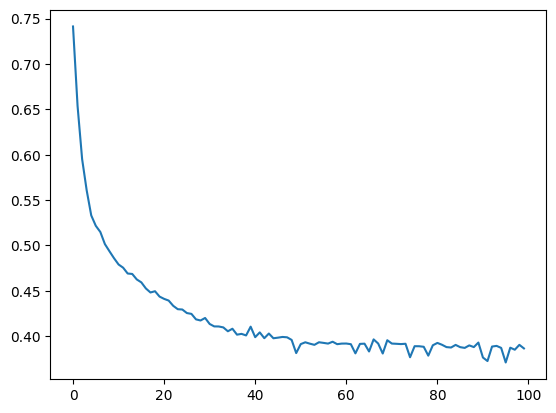

In [4]:
sns.lineplot(val_loss_list_1)
plt.show()

## Generation of 100 previous images discarting the dislocated image

In [5]:
number_of_legs = 101
convolutional_features = static_df.copy()

val_loss_list_2 = []
val_r2_list_2 = []

for i in range(1, number_of_legs):

    x_train, x_test, y_train, y_test = train_test_split(convolutional_features.drop(['y', 'current', 'nozzle_speed', 'mass_flow_rate', 'experiment'], axis=1), convolutional_features['y'], train_size=0.7, random_state=42)

    model = keras.Sequential([
        keras.layers.Input(shape=(1536+i-1,)),  # Input layer
        keras.layers.Dense(32, activation='relu'),  # Hidden layer with 32 neurons and ReLU activation
        keras.layers.Dense(1)                  # Output layer with a single neuron (for regression)
    ])

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        verbose=0,
        mode="auto",
        baseline=None,
        restore_best_weights=True,
        start_from_epoch=0,
    )

    model.compile(optimizer='adam', loss='mean_absolute_error')
    model.fit(x_train, y_train, epochs=300, batch_size=128, validation_data=(x_test, y_test), callbacks=[early_stopping], verbose=0)

    test_loss = model.evaluate(x_test, y_test)
    print(f"Test Loss {i}: {test_loss:.4f}")

    y_pred = model.predict(x_test, verbose=0)
    val_loss_list_2.append(mean_absolute_error(y_test, y_pred))
    val_r2_list_2.append(r2_score(y_test, y_pred))

    extended_convolutional_features_list = []
    final_dislocated_predictions = []
    for target in convolutional_features['experiment'].unique():
        segmented_convolutional_features = convolutional_features[convolutional_features['experiment'] == target].copy()
        segmented_y_pred = list(model.predict(segmented_convolutional_features.drop(['y', 'current', 'nozzle_speed', 'mass_flow_rate', 'experiment'], axis=1), verbose=0))
        mean_y = segmented_convolutional_features['y'].mean()
        dislocated_ypred = [mean_y] * i
        dislocated_ypred.extend([pred[0] for pred in segmented_y_pred])
        dislocated_ypred = dislocated_ypred[:segmented_convolutional_features.shape[0]]
        final_dislocated_predictions.extend(dislocated_ypred)

    convolutional_features[str(1536+i-1)] = final_dislocated_predictions

    filtered_dfs = []
    for e in convolutional_features['experiment'].unique():
        filtered_experiment_df = convolutional_features[convolutional_features['experiment'] == e].iloc[1:, :].copy()
        filtered_dfs.append(filtered_experiment_df)
    
    convolutional_features = pd.concat(filtered_dfs).reset_index(drop=True)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 753us/step - loss: 0.7076
Test Loss 1: 0.7076
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step - loss: 0.6325
Test Loss 2: 0.6325


2026-04-04 17:09:46.344044: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 4 bytes spill stores, 4 bytes spill loads

2026-04-04 17:09:46.344729: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 24 bytes spill stores, 24 bytes spill loads

2026-04-04 17:09:46.409496: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 4 bytes spill stores, 4 bytes spill loads

2026-04-04 17:09:46.759119: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 4 bytes spill stores, 4 bytes spill loads

2026-04-04 17:09:46.802828: I external/local_xla/xla/strea

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - loss: 0.5759
Test Loss 3: 0.5759


2026-04-04 17:10:03.450057: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_81', 8 bytes spill stores, 8 bytes spill loads



201/250 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - loss: 0.5445

...

2026-04-04 17:49:42.429995: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:49:42.473840: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:49:42.910698: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:49:42.912907: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:49:43.767786: I external/local_xla/xla/stream_

242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - loss: 0.3205
Test Loss 99: 0.3205
201/242 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step - loss: 0.3191

2026-04-04 17:50:48.851024: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_13', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:50:48.857645: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_13', 8 bytes spill stores, 8 bytes spill loads



242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3145 
Test Loss 100: 0.3145


2026-04-04 17:50:49.721279: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:50:49.735567: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:50:50.660911: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:50:50.714922: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:50:51.307801: I external/local_xla/xla/stream_

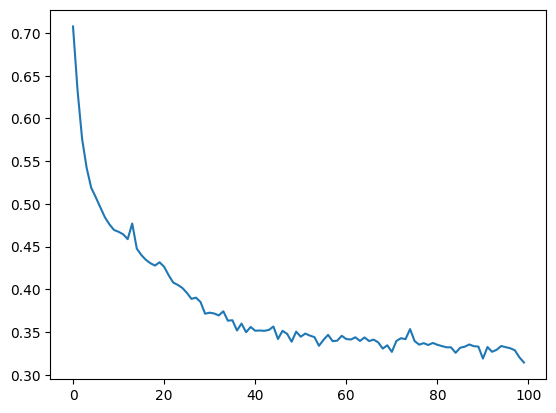

In [6]:
sns.lineplot(val_loss_list_2)
plt.show()

## Generation of 100 previous images discarting the dislocated images and unstable melt pool region images

In [7]:
number_of_legs = 101

convolutional_features = static_df.copy()

filtered_convolutional_features_dfs = []

for e in convolutional_features['experiment'].unique():
    experiment_df = convolutional_features[convolutional_features['experiment'] == e]
    lower_limit = int(np.ceil(experiment_df.shape[0] * 0.20))
    upper_limit = int(np.ceil(experiment_df.shape[0] * 0.90))
    filtered_experiment_df = experiment_df.iloc[lower_limit: upper_limit, :].copy()
    filtered_convolutional_features_dfs.append(filtered_experiment_df)

convolutional_features = pd.concat(filtered_convolutional_features_dfs)

val_loss_list_3 = []
val_r2_list_3 = []

for i in range(1, number_of_legs):

    x_train, x_test, y_train, y_test = train_test_split(convolutional_features.drop(['y', 'current', 'nozzle_speed', 'mass_flow_rate', 'experiment'], axis=1), convolutional_features['y'], train_size=0.7, random_state=42)

    model = keras.Sequential([
        keras.layers.Input(shape=(1536+i-1,)),  # Input layer
        keras.layers.Dense(32, activation='relu'),  # Hidden layer with 32 neurons and ReLU activation
        keras.layers.Dense(1)                  # Output layer with a single neuron (for regression)
    ])

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        verbose=0,
        mode="auto",
        baseline=None,
        restore_best_weights=True,
        start_from_epoch=0,
    )

    model.compile(optimizer='adam', loss='mean_absolute_error')
    model.fit(x_train, y_train, epochs=300, batch_size=128, validation_data=(x_test, y_test), callbacks=[early_stopping], verbose=0)

    test_loss = model.evaluate(x_test, y_test)
    print(f"Test Loss {i}: {test_loss:.4f}")

    y_pred = model.predict(x_test, verbose=0)
    val_loss_list_3.append(mean_absolute_error(y_test, y_pred))
    val_r2_list_3.append(r2_score(y_test, y_pred))

    extended_convolutional_features_list = []
    final_dislocated_predictions = []
    for target in convolutional_features['experiment'].unique():
        segmented_convolutional_features = convolutional_features[convolutional_features['experiment'] == target].copy()
        segmented_y_pred = list(model.predict(segmented_convolutional_features.drop(['y', 'current', 'nozzle_speed', 'mass_flow_rate', 'experiment'], axis=1), verbose=0))
        mean_y = segmented_convolutional_features['y'].mean()
        dislocated_ypred = [mean_y] * i
        dislocated_ypred.extend([pred[0] for pred in segmented_y_pred])
        dislocated_ypred = dislocated_ypred[:segmented_convolutional_features.shape[0]]
        final_dislocated_predictions.extend(dislocated_ypred)

    convolutional_features[str(1536+i-1)] = final_dislocated_predictions

    filtered_dfs = []
    for e in convolutional_features['experiment'].unique():
        filtered_experiment_df = convolutional_features[convolutional_features['experiment'] == e].iloc[1:, :].copy()
        filtered_dfs.append(filtered_experiment_df)
    
    convolutional_features = pd.concat(filtered_dfs).reset_index(drop=True)

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.6500
Test Loss 1: 0.6500


2026-04-04 17:51:09.382487: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:51:09.385021: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 12 bytes spill stores, 12 bytes spill loads

2026-04-04 17:51:09.724266: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 12 bytes spill stores, 12 bytes spill loads

2026-04-04 17:51:09.735963: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 17:51:10.377150: I external/local_xla/xla/str

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step - loss: 0.5297
Test Loss 2: 0.5297


2026-04-04 17:51:24.487252: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 20 bytes spill stores, 20 bytes spill loads

2026-04-04 17:51:24.921435: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 24 bytes spill stores, 24 bytes spill loads

2026-04-04 17:51:24.974917: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 4 bytes spill stores, 4 bytes spill loads



175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step - loss: 0.4512
Test Loss 3: 0.4512
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step - loss: 0.4100
Test Loss 4: 0.4100


...

2026-04-04 18:21:33.567836: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 18:21:33.600285: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads



167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - loss: 0.2810
Test Loss 99: 0.2810


2026-04-04 18:21:47.654925: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 12 bytes spill stores, 12 bytes spill loads

2026-04-04 18:21:48.763327: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads



167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2774 
Test Loss 100: 0.2774


2026-04-04 18:22:11.804054: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 18:22:11.810107: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 18:22:12.985290: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 18:22:12.989444: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2026-04-04 18:22:13.098495: I external/local_xla/xla/stream_

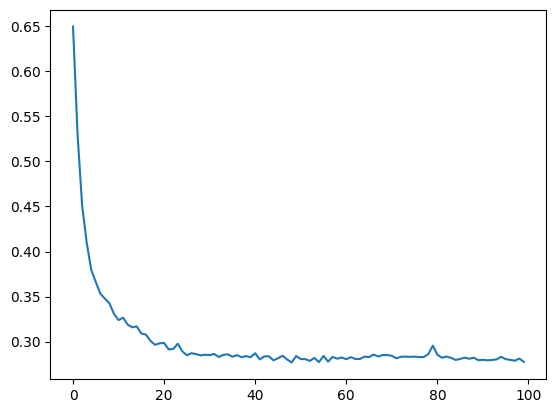

In [8]:
sns.lineplot(val_loss_list_3)
plt.show()